In [1]:
import awkward as ak
import vector
vector.register_awkward()
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import hist
import mplhep as hep
import pandas as pd
hep.style.ROOT
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from plotting import *
print(matplotlib.__version__)

%load_ext autoreload
%autoreload 2

3.9.2


In [2]:
hpString = "HS"
psString = "PS"
hadString = "HAD"


In [3]:
def get_lb_pair(jets, leptons, bhadrons):
    
    jets_sel = jets[jets.pt > 30]
    
    # Build Jet x Bhadron pairs: events -> jets -> bhadrons
    pairs_jb = ak.cartesian(
        {"j": jets_sel, "bh": bhadrons},
        axis=1,
        nested=True,
    )
    
    dr_jb = pairs_jb["j"].deltaR(pairs_jb["bh"])
    
    has_bhadron = ak.any(dr_jb < 0.4, axis=2)
    
    bjets = jets_sel[has_bhadron]
    
    leptons_sel = leptons[leptons.pt > 25]
    
    # events -> leptons -> bjets
    pairs_lb = ak.cartesian(
        {"l": leptons_sel, "b": bjets},
        axis=1,
        nested=True,
    )
    
    dr_lb = ak.fill_none(pairs_lb["l"].deltaR(pairs_lb["b"]), np.inf)
    idx = ak.argmin(dr_lb, axis=2)                 # events→L
    best_b = bjets[idx]
    drmin_lb = ak.min(dr_lb, axis=2, initial=np.inf)

    valid_pair = (
    ~ak.is_none(best_b, axis=1)
    & (drmin_lb > 0.4)
    )

    sel = ak.any(valid_pair, axis=1)
    
    m_lb = (leptons_sel + best_b).mass
    m_lb = m_lb[valid_pair]
    
    return m_lb[sel, 0], sel

In [4]:
def find_nearest(obj1, obj2):
    #### get dRs
    dR = obj1.deltaR(obj2)
    #### mask where dR to self
    dR = ak.where(dR == 0, None, dR)
    idx = ak.argmin(dR, axis=-1)
    nearest_other = obj2[idx]
    return nearest_other

In [5]:
def sigmoid(x ,L, x0, k):
    y = L / (1 + np.exp(-k*(x-x0)))
    return (y)
def get_fracs(radii, weights, weights_orig):
    fracs = []
    for R, weight in zip(radii, weights):
        # print("orig neg weights ", ak.sum(weights<0))
        # print("n orig weights ", len(weights))
        # print("Frac orgi negative weights ", ak.sum(weights_orig<0)/len(weights))
        frac = (1-ak.sum(weight<0)/ak.sum(weights_orig<0))
        fracs.append(round(frac, 2))
    return fracs
def fit_sigmoid(radii, frac, des_frac=25, string=""):
    print(frac)
    ###initial guess
    if frac[0]>1.:
        frac.insert(0, 0)
        radii.insert(0,0)
    p0 = [max(frac), np.median(np.array(radii)),1]
    popt, pcov = curve_fit(sigmoid, np.array(radii), frac, p0)
    L, x0, k = popt
    if (L/(des_frac-k))-1 > 0:
        x = x0-((1/k)*np.log((L/(des_frac))-1))
        print(f"{string} x value where y = {des_frac}: {x}")
    else:
        print(f"No real solution for y = {des_frac} with sigmoid fit.")
    return popt, pcov
# def plot_cellradius_comp():
def sigmoid_Lfixed(x, x0, k, L=100.0):
    # clip exponent to avoid overflow warnings
    z = np.clip(-k*(x-x0), -700, 700)
    return L / (1.0 + np.exp(z))
def fit_sigmoid_fixedL(radii, fracs, L=100.0, des_frac=25):
    # initial guesses
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
    p0 = [np.median(np.array(radii)),1]

    # bounds: x0 within radii range (with padding), k positive
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = ([np.min(radii) - pad, 1e-6], [np.max(radii) + pad, 10.0])

    popt, pcov = curve_fit(lambda x, x0, k: sigmoid_Lfixed(x, x0, k, L=L),
                           radii, fracs, p0=p0, bounds=bounds)

    x0, k = popt
    return (L, x0, k), pcov
def richards(x, x0, k, nu, L=1.0):
    z = -k*(x-x0)
    return L / (1.0 + np.exp(z))**(1.0/nu)
def fit_richards(radii, fracs, L=1.0):
    x0_guess = np.median(radii)
    k_guess  = 2/np.median(radii)
    nu_guess = 1.0
        # optional: let L float, or fix it to max observed
    if L is None:
        L = fracs.max()
    if fracs[0]>1.:
        fracs.insert(0,0)
        radii.insert(0,0)
   
    pad = (np.max(radii) - np.min(radii)) if len(radii) > 1 else 10.0
    bounds = (
        [np.min(radii)-pad, 1e-3, 0.05],   # x0, k, nu
        [np.max(radii)+pad, 10.0/np.median(radii), 20.0]
    )

    popt, pcov = curve_fit(lambda x, x0, k, nu: richards(x, x0, k, nu, L=L),
                           radii, fracs, p0=[x0_guess, k_guess, nu_guess], bounds=bounds)
    return (*popt, L), pcov
def richards_x_at_y(y, x0, k, nu, L):
    y = float(y)
    if not (0.0 < y < L) or k == 0 or nu <= 0:
        return np.nan
    arg = (L / y)**nu - 1.0
    if arg <= 0:
        return np.nan
    return x0 - (1.0 / k) * np.log(arg)

In [6]:
def make_df(radii, weights_orig, inputpath0, inputpath1 = "gev_bigR.npy", points = "None"):
    weights = []
    for R in radii:
        str_R = str(R).replace(".", "p")
        weight = np.load(inputpath0+str_R+inputpath1)
        if type(points)!=str:
            weight = fix_weight_length(points, weight, weights_orig)
        weights.append(weight)
    fracs = get_fracs(radii, weights, weights_orig)
    df = pd.DataFrame({
        "radius": radii,
        "fraction": fracs,
        "weights": weights
    })
    return df
def fix_weight_length(points, weights, weights_orig):
    mask = np.all(points == 0, axis=(1, 2))
    if len(weights) != len(weights_orig):
        rw_weights = weights_orig.copy()
        print("Masking out zero values to fix different lengths: ", mask.shape, rw_weights.shape, weights.shape)
        rw_weights[~mask] = weights
        return rw_weights
    else:
        return weights

In [7]:
##### Load jets
# ttbar_jets = ak.from_parquet('/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_NLO_100k_alljetsV1.parquet')
# order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
# jets = ttbar_jets[order]

ttbar_jets = ak.from_parquet('~/NegativeWeights/ttbar_NLO_100k_alljetsV2.parquet')
order = ak.argsort(ttbar_jets.pt, axis=1, ascending=False)
jets = ttbar_jets[order]

bhadrons = ak.from_parquet('~/NegativeWeights/ttbar_NLO_100k_bhadrons.parquet')
leptons = ak.from_parquet('~/NegativeWeights/ttbar_NLO_100k_leptons.parquet')

print(len(bhadrons)==len(ttbar_jets))
#### load original weights for ttbar, z+jet
N=10000

weights_orig_ttbar = np.load("/oscar/data/mleblan6/lhay/ttbar_100k/ttbar_weight_100k.npy")

print(np.sum(weights_orig_ttbar))
#### making the ttbar hp dataframes
dataFrames = {}
radii_hp = [5,15,17,18.5,20,22,25,30,100]
ttbar_hp_df = make_df(radii_hp, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_hp_100k/100k_hp_emd_reweight_")
dataFrames["ttbar_hp_df"] = {"process": "TTbar", "df": ttbar_hp_df, "title": r"EMD $\beta=1$ %s "%hpString}
#### print the available fractions
print(ttbar_hp_df["fraction"].values)
#### if you would like to look up by fraction
df_f = ttbar_hp_df.set_index("fraction")
w_f = df_f.loc[0.71, "weights"]

#### make rest of ttbar dataframes

radii_ps = [1, 15, 18, 24, 25, 29, 30, 36,  50, 100]
ttbar_ps_df = make_df(radii_ps, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_ps_100k/100k_ps_emd_reweight_", "gev_ttbar.npy")
dataFrames["ttbar_ps_df"] = {"process": "TTbar", "df": ttbar_ps_df, "title": r"EMD $\beta=1$ %s "%psString}

radii_had = [1, 10, 18, 20, 25, 28, 29, 30, 35, 50, 100]
ttbar_had_df = make_df(radii_had, weights_orig_ttbar, "/oscar/data/mleblan6/lhay/reweighted_files/ttbar_had_100k/100k_had_emd_reweight_", "gev_ttbar.npy")
print(ttbar_had_df['fraction'].values)
dataFrames["ttbar_had_df"] = {"process": "TTbar", "df": ttbar_had_df, "title": r"EMD $\beta=1$ %s "%hadString}
radii_had_10k = [1, 21, 25, 28, 30, 50]
ttbar_had_10k_df = make_df(radii_had_10k, weights_orig_ttbar[0:10000], "/oscar/data/mleblan6/lhay/reweighted_files/10k_ttbar_had/10k_had_emd_reweight_", "gev_ttbar.npy")



True
678.6208346399999
[0.   0.07 0.17 0.25 0.37 0.53 0.71 0.87 1.  ]
[0.   0.   0.   0.02 0.25 0.42 0.47 0.53 0.72 0.94 1.  ]


In [8]:
obsDict = {}
njets = max(ak.num(jets.pt, axis=1))

nosel = (ak.num(jets.pt, axis=1)>-5)

sel_twojets = (ak.num(jets.pt, axis=1)>1)
sel_jets_twojets = jets[sel_twojets]

sel_onejet = (ak.num(jets.pt, axis=1)>0)
sel_jets_onejet = jets[sel_onejet]

mlb, sel_lb = get_lb_pair(jets, leptons, bhadrons)

quantity="m_{tt}"
sel_ttjets = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel_ttjets]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000




obsDict["drjj"] = {"name": r"\Delta R_{j_0, j_1}", "xmin": 0, "xmax": 10, "numbins": 20, "ratioLim": [0.75,1.25], "obs": np.sqrt((sel_jets_twojets.eta[:,0] - sel_jets_twojets.eta[:,1])**2 + (sel_jets_twojets.phi[:,0] - sel_jets_twojets.phi[:,1])**2), "sel":sel_twojets}
obsDict["njets"] = {"name": "N_{jets}", "xmin": 0, "xmax": njets, "numbins": njets, "ratioLim": [0.75,1.25], "obs": ak.num(jets.pt, axis=1), "sel":nosel}
obsDict["ptlead"] = {"name": "p_{T,j_0}", "xmin": 20, "xmax": 500, "numbins": 20, "ratioLim": [0.75,1.25], "obs": sel_jets_onejet.pt[:,0], "sel": sel_onejet}
obsDict["ht"] = {"name": "H_T", "xmin": 10, "xmax": 3000, "numbins": 20, "ratioLim": [0.75,1.25], "obs": ak.sum(jets.pt, axis=-1), "sel": nosel}
obsDict["mtt"] = {"name": "m_{tt}", "xmin": 0, "xmax": 2000, "numbins": 20, "ratioLim": [0.75,1.25], "obs": mtt, "sel": sel_ttjets}
obsDict["mlb"] = {"name": "m_{lb}", "xmin": 0, "xmax": 300, "numbins": 24, "ratioLim": [0.75,1.25], "obs": mlb, "sel": sel_lb}
obsDict["ptrat"] = {"name": "p_{T0}/p_{T1}", "xmin": 1, "xmax": 4.5, "numbins": 14, "ratioLim": [0.75,1.25], "obs": sel_jets_twojets.pt[:,0]/sel_jets_twojets.pt[:,1], "sel": sel_twojets}

In [9]:
processDict = {}

processDict["TTbar"] = {"name": "TTbar", "weights": weights_orig_ttbar}

In [10]:
comparisonDict = {}

comparisonDict["stages"] = {"weights": ["ttbar_hp_df", "ttbar_ps_df", "ttbar_had_df"], "maxCellRadius":100}



EMD $\beta=1$ HS  R for 0.5 RW  21.716
EMD $\beta=1$ PS  R for 0.5 RW  29.338
EMD $\beta=1$ HAD  R for 0.5 RW  29.637


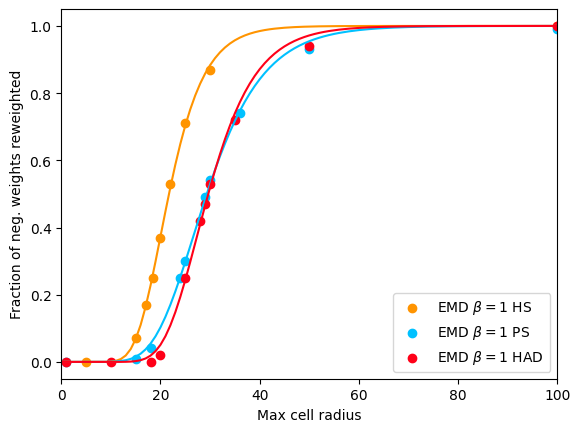

In [11]:

cmap  = tuple(tuple(c) for c in plt.cm.hsv(np.linspace(0.1, 1.0, 3)))
for comparison in comparisonDict:
    rw_dict_strings = comparisonDict[comparison]["weights"]
    rw_dicts = []
    strings = []
    for sample in rw_dict_strings:
        rw_dicts.append(dataFrames[sample]["df"])
        strings.append(dataFrames[sample]["title"])
    
    maxCellRadius = comparisonDict[comparison]["maxCellRadius"]
    for i, df in enumerate(rw_dicts):
        frac = df["fraction"].values
        radii = df["radius"].values
        plt.scatter(radii, frac, color=cmap[i], label = strings[i])
        popt, pcov = fit_richards(radii, frac)
        x = np.arange(-5,np.max(radii)*1.5)
        if(max(radii) < 20):
          x = np.arange(0,np.max(radii)*1.5*10000)/10000
        frac=0.5
        print(f"{strings[i]} R for {frac} RW ", round(richards_x_at_y(frac, *popt), 3))
        plt.plot(x, richards(x, *popt), color=cmap[i], linestyle='-')
    plt.xlabel("Max cell radius")
    plt.xlim(0, maxCellRadius)
    plt.ylabel("Fraction of neg. weights reweighted")
    plt.legend()
    plt.show()

/oscar/home/lhay/cres-distance/cell_reweighting_scripts/plotting.py:131: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax, rax) = plt.subplots(nrows=2,


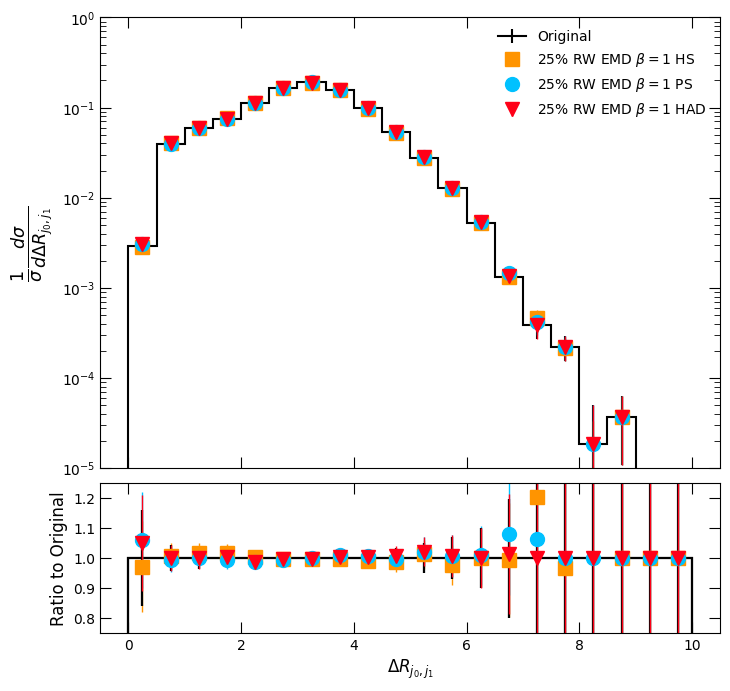

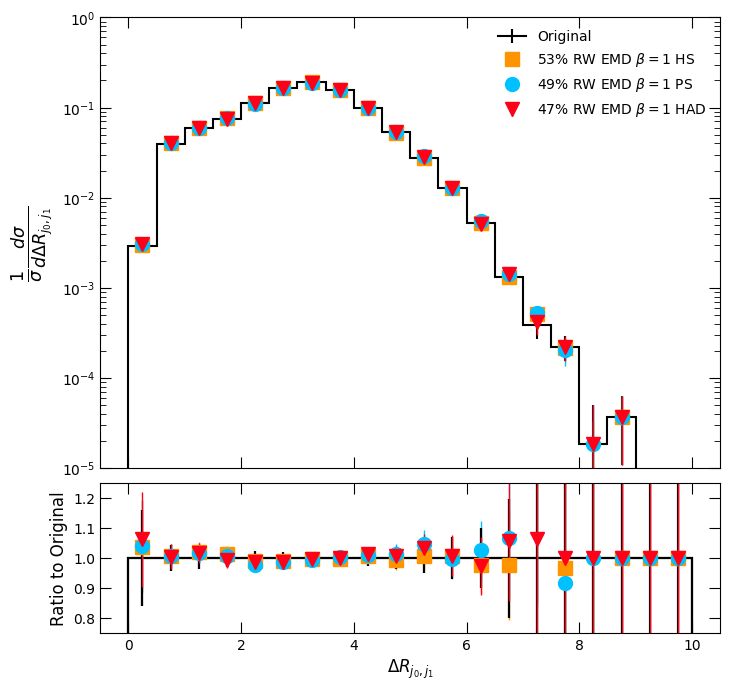

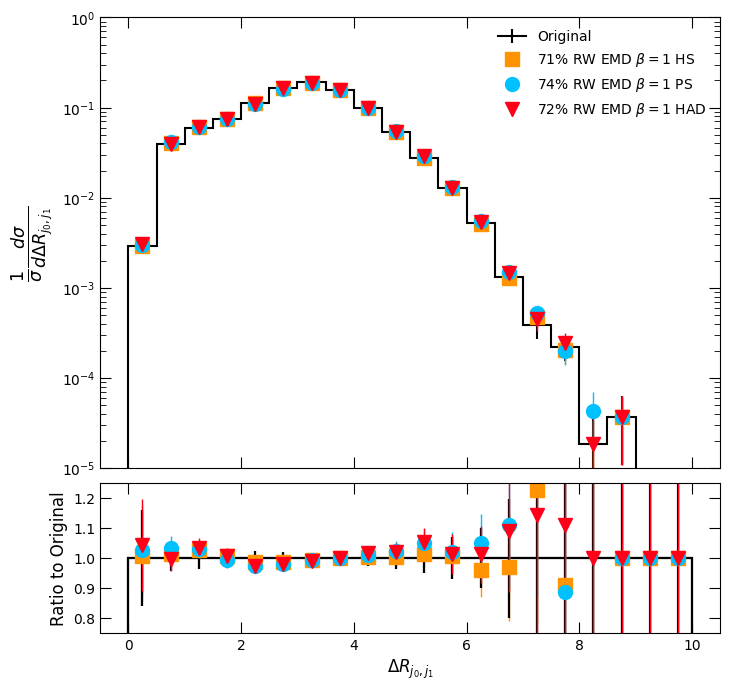

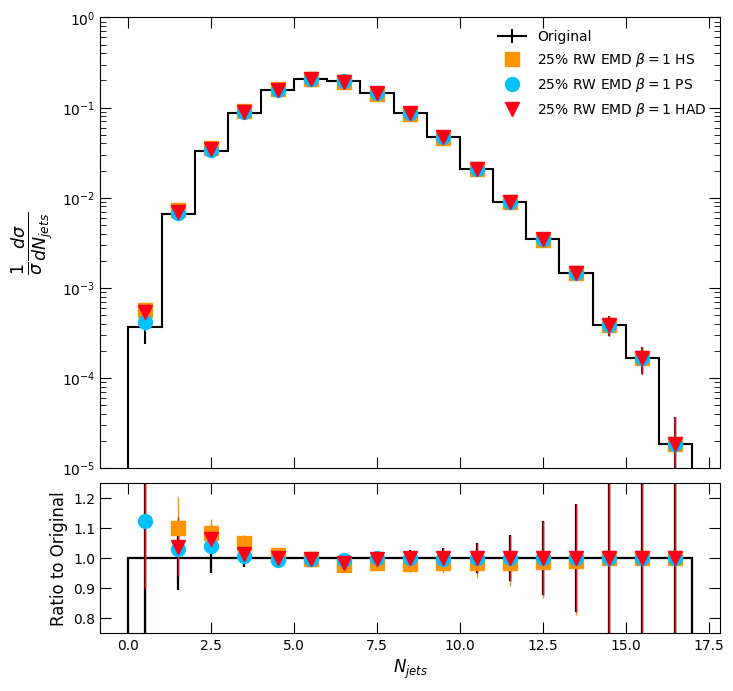

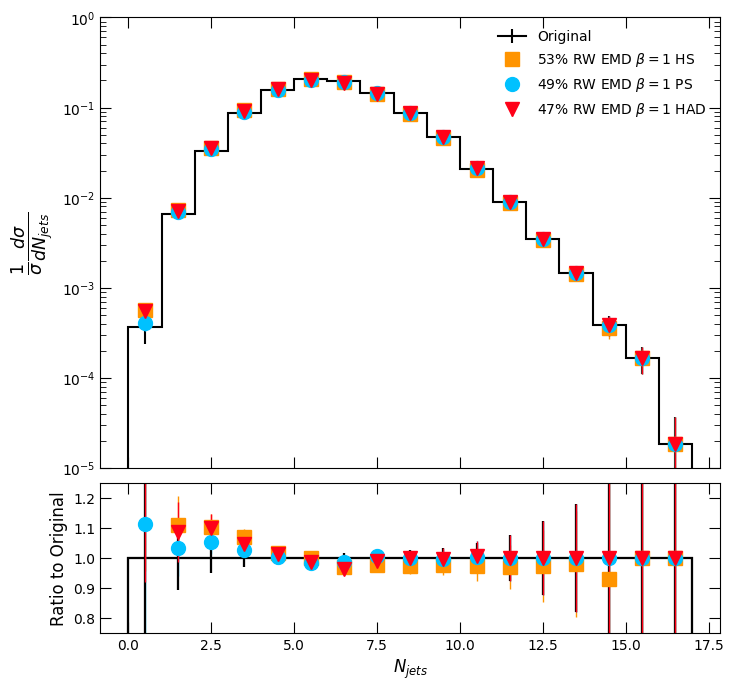

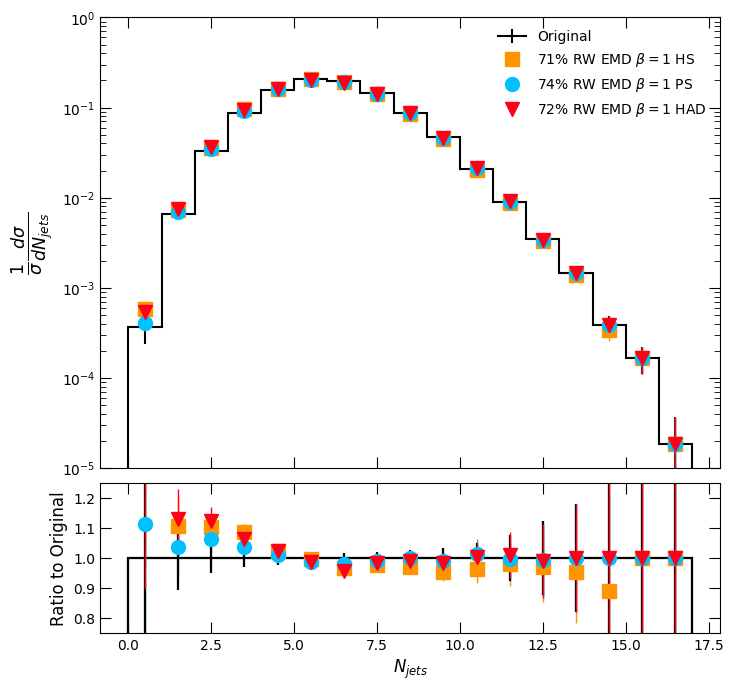

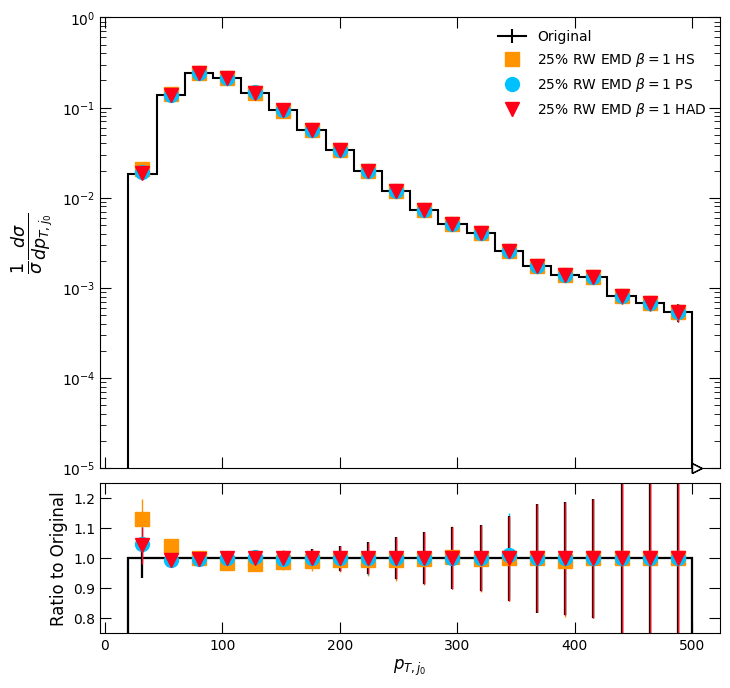

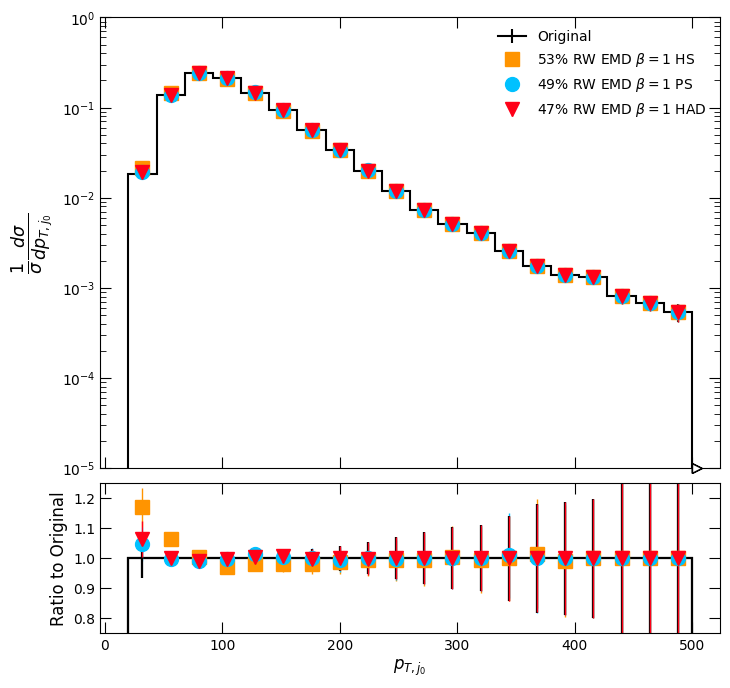

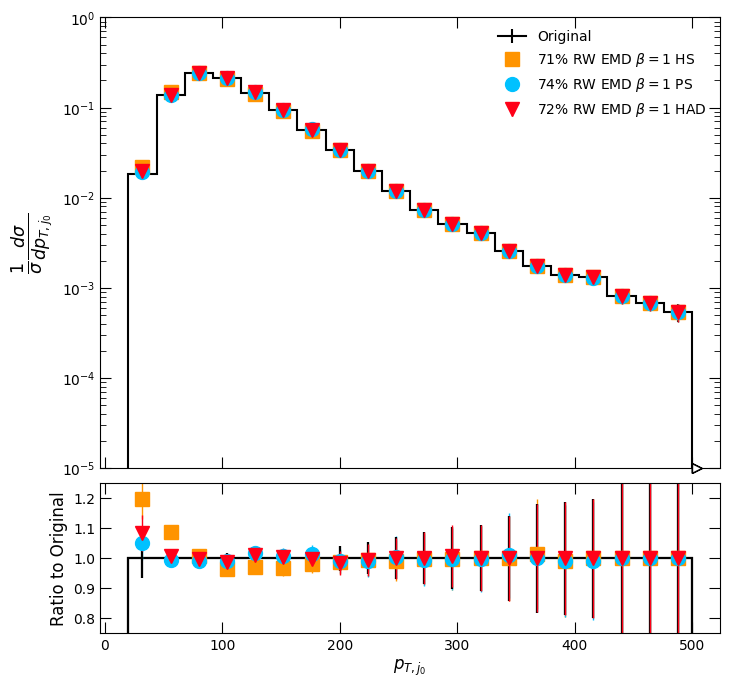

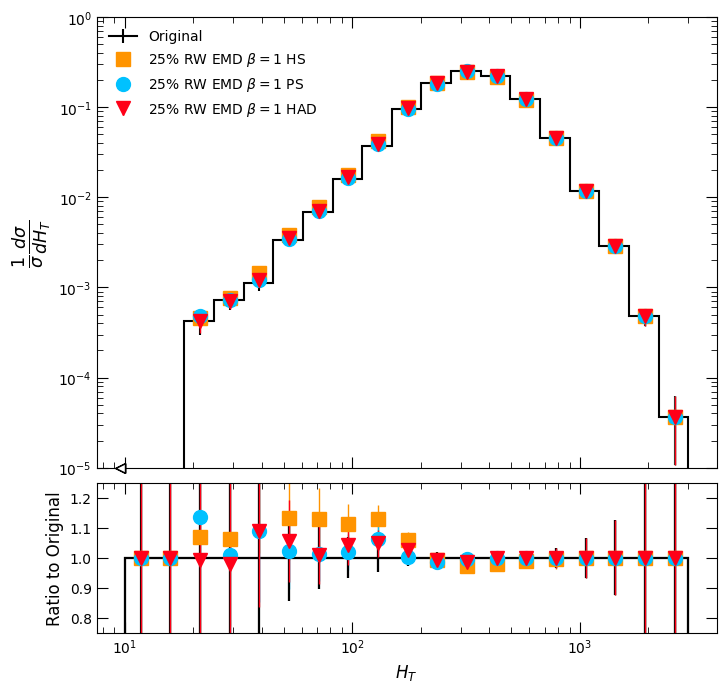

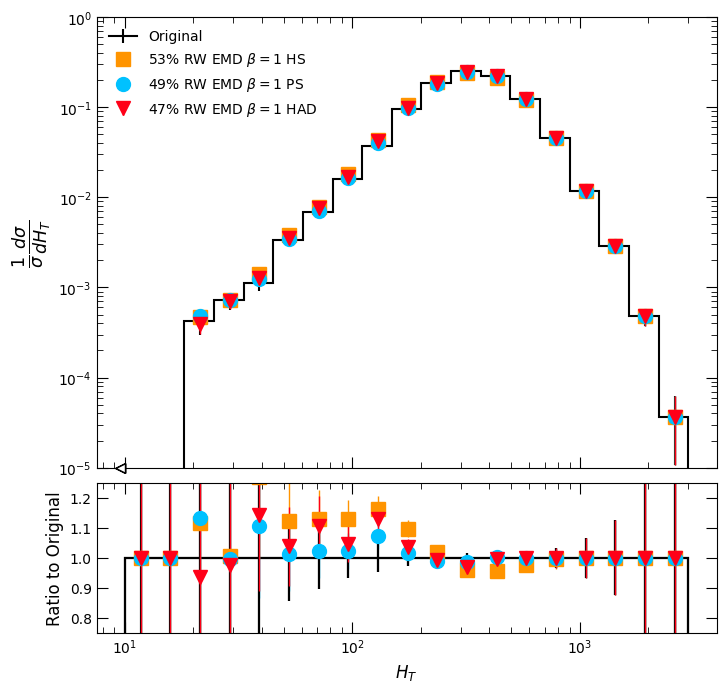

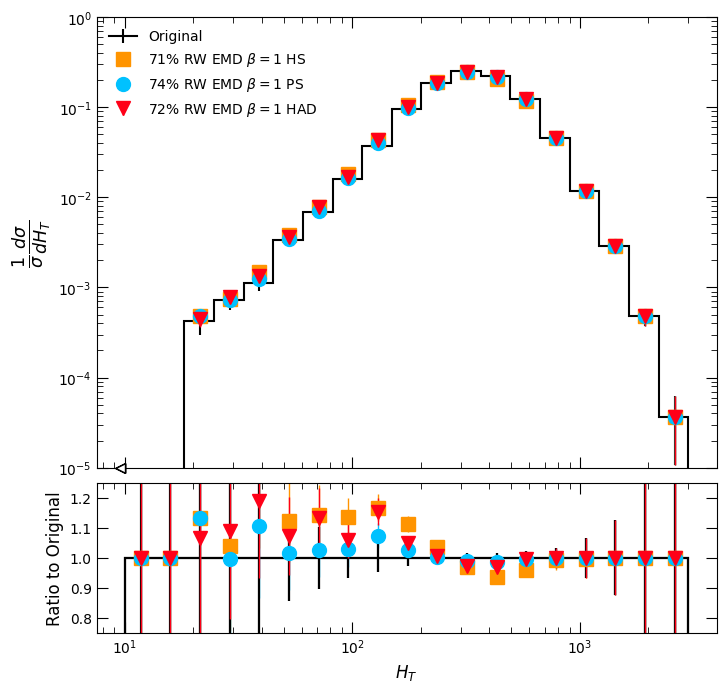

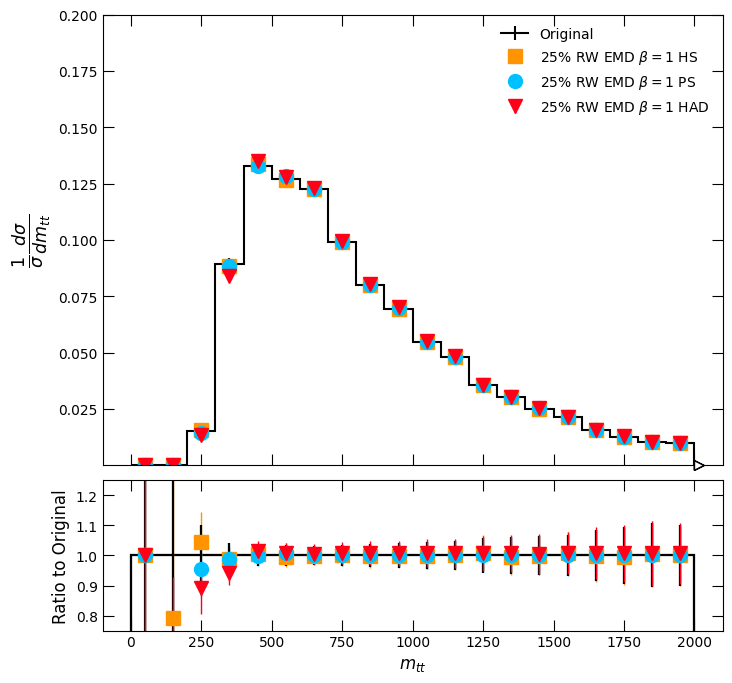

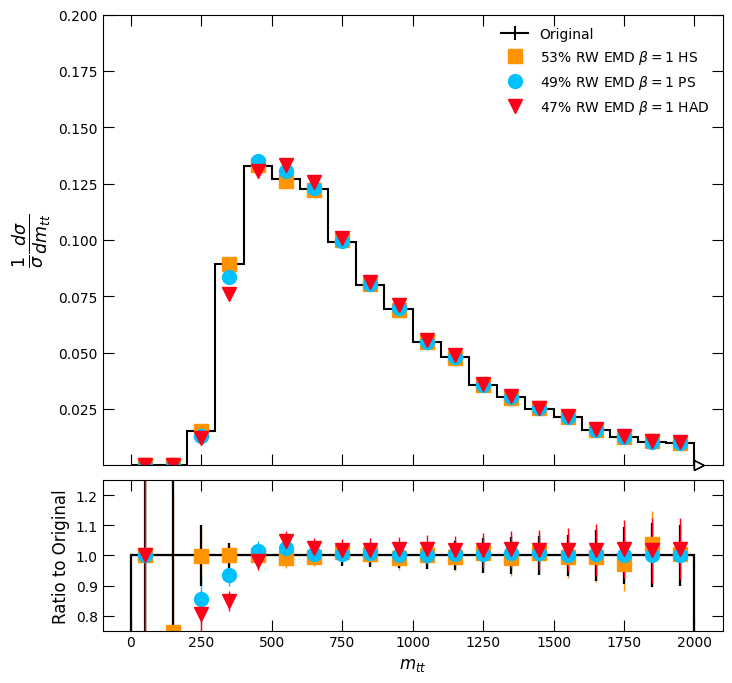

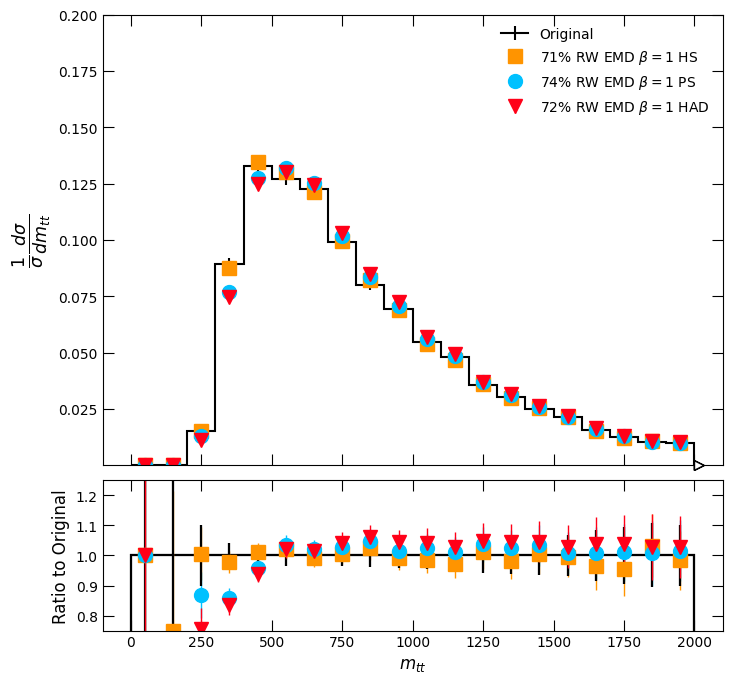

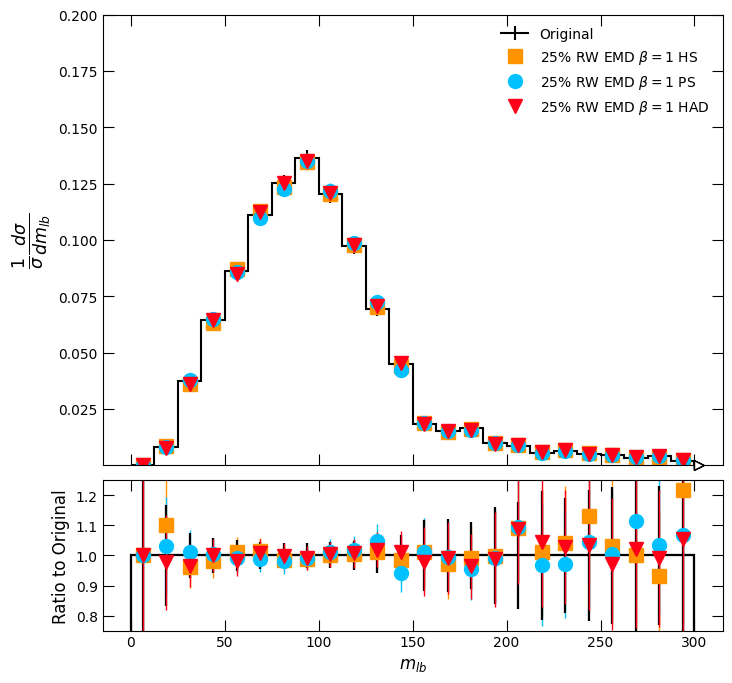

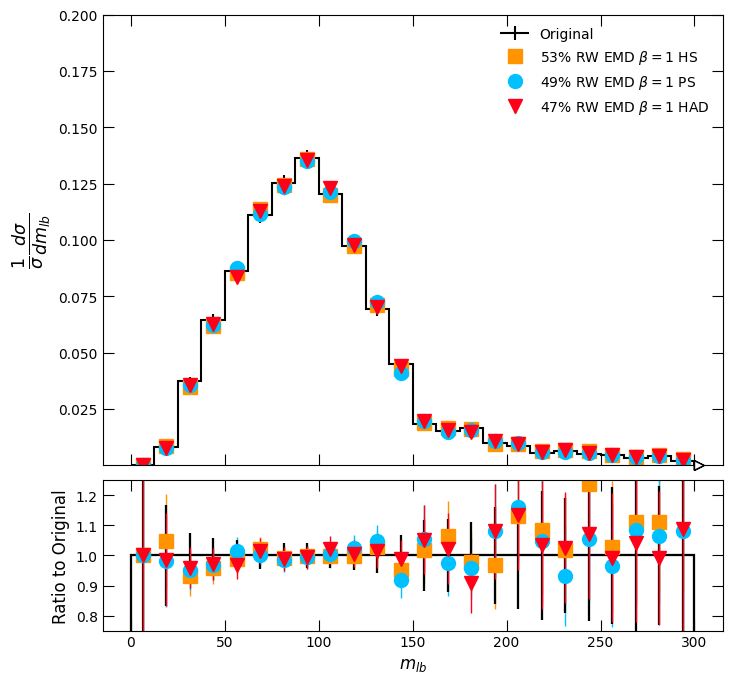

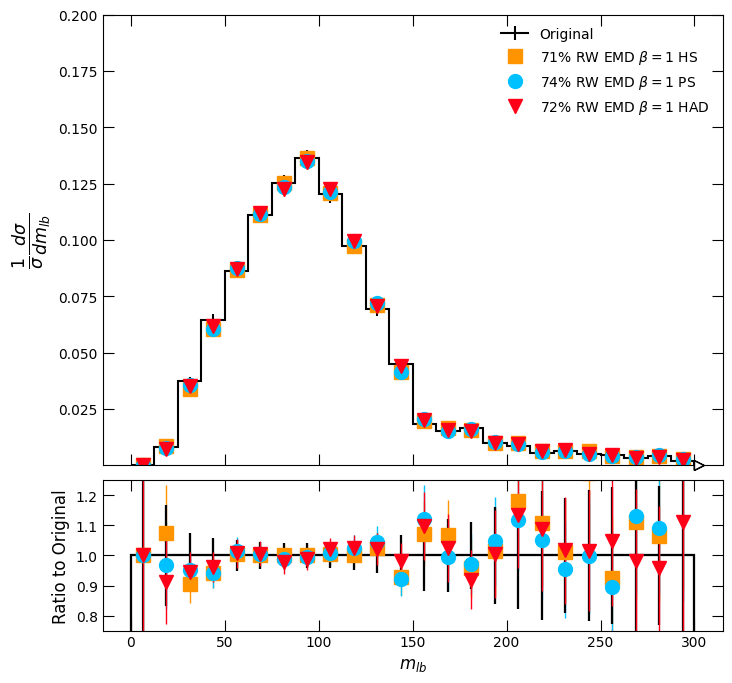

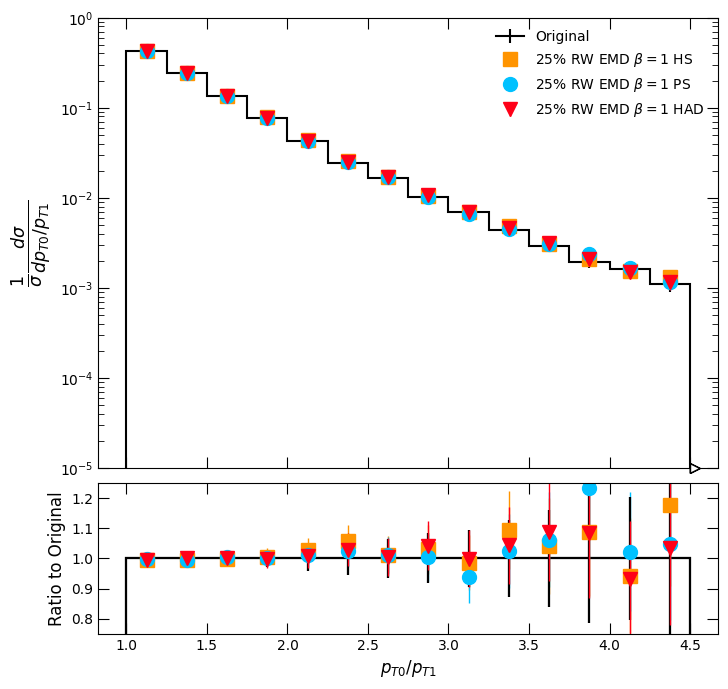

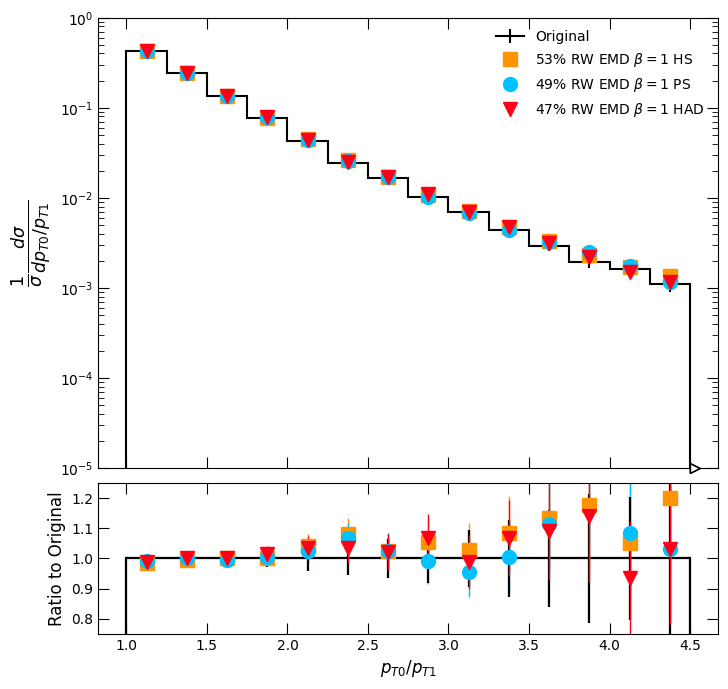

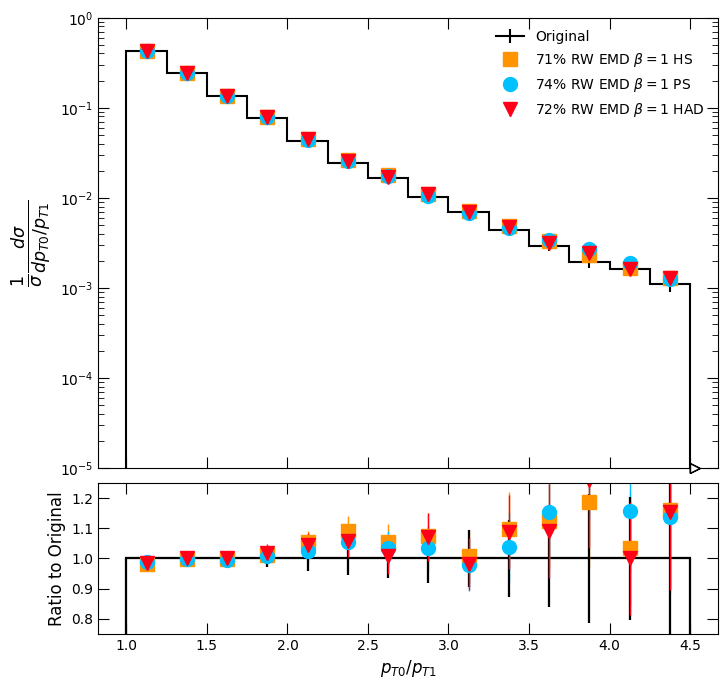

In [12]:
rwFracs = [0.25, 0.5, 0.75]
for comparison in comparisonDict:
    for observable in obsDict:
        if observable == "mtt" or observable=="mlb":
            logy=False
            ymax=0.2
        else:
            logy=True
            ymax=1
        if observable == "ht":
            logx=True
        else:
            logx=False
        for rwFrac in rwFracs:
            xmin = obsDict[observable]["xmin"]
            xmax = obsDict[observable]["xmax"]
            numbins = obsDict[observable]["numbins"]
            obs_str = obsDict[observable]["name"]
            obs= obsDict[observable]["obs"]
            sel = obsDict[observable]["sel"]
            ratioLim = obsDict[observable]["ratioLim"]
        
            rw_dict_strings = comparisonDict[comparison]["weights"]

            # I'm sure there's a better way to do this in python but I don't care enough
            dfs = []
            process_str = []
            processes = []
            for sample in rw_dict_strings:
                dfs.append(dataFrames[sample]["df"])
                process_str.append(dataFrames[sample]["title"])
                processes.append(dataFrames[sample]["process"])


            processWeights = processDict[processes[0]]["weights"]
            processTitle = processDict[processes[0]]["name"]
            isSameProcess = True
            for process in processes:
                if process != processes[0]:
                    print("Mixed processes -- this script requires rewriting to work in this context")
                    isSameProcess= False
                    break
            if not isSameProcess:
                break


            plot_diff_rw(obs, dfs, process_str, processWeights, xmin, xmax, numbins, sel=sel, obs_str = obs_str, obs_title = observable, process_title = processTitle, title = comparison, channel = processes[0], raxlim=ratioLim, rwFrac=rwFrac, logx=logx, logy=logy, ymax=ymax)

       

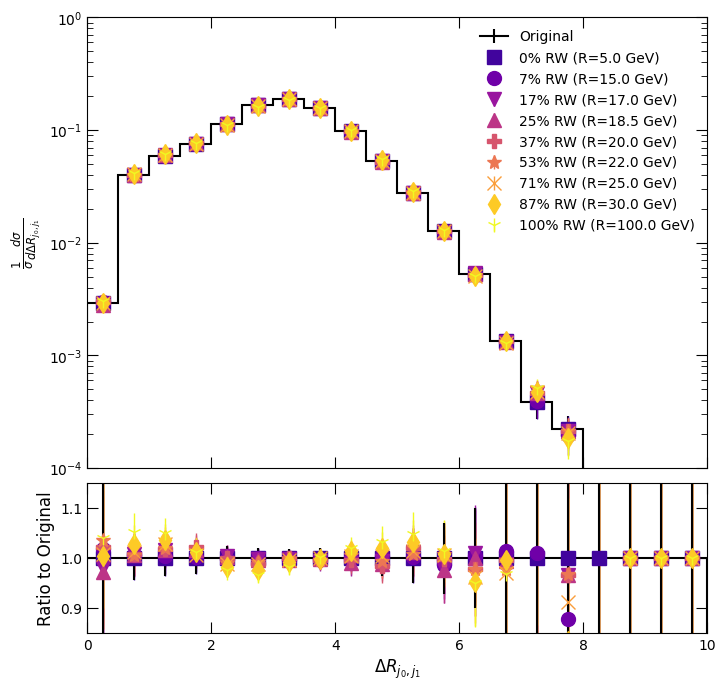

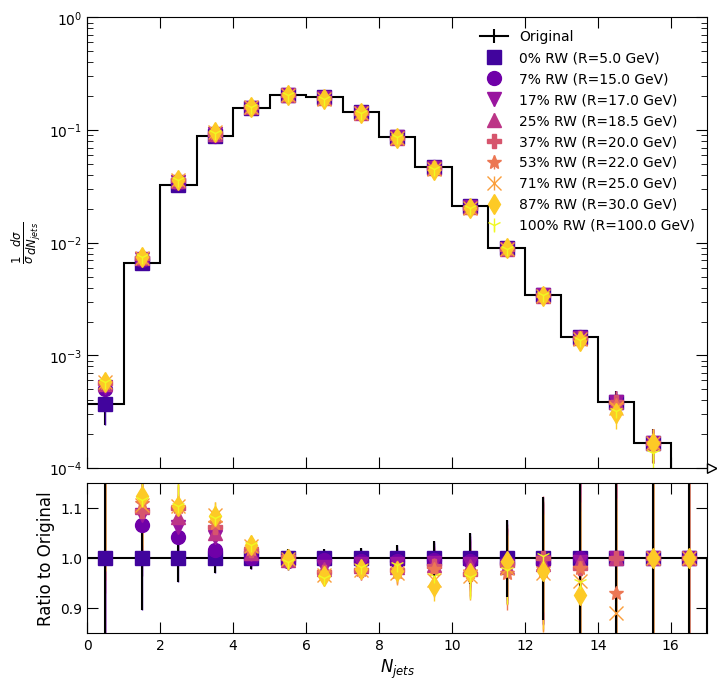

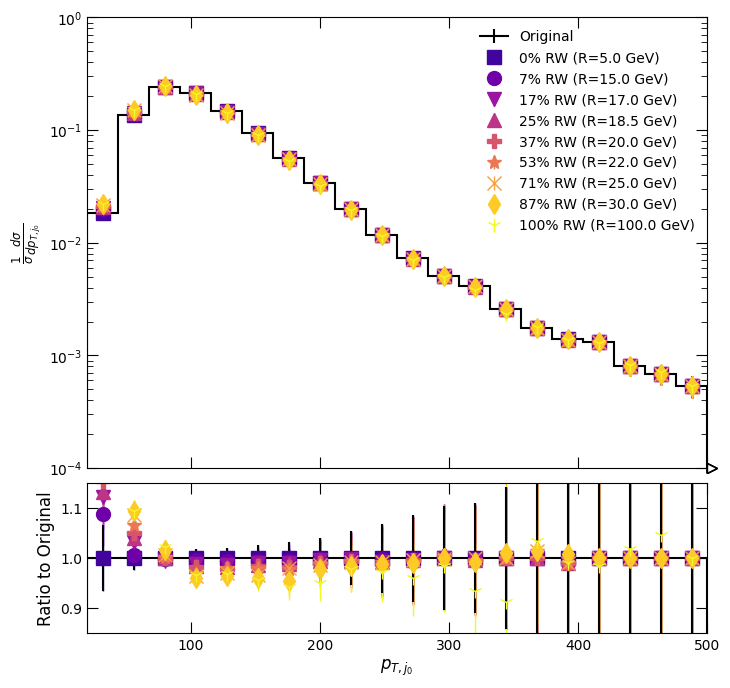

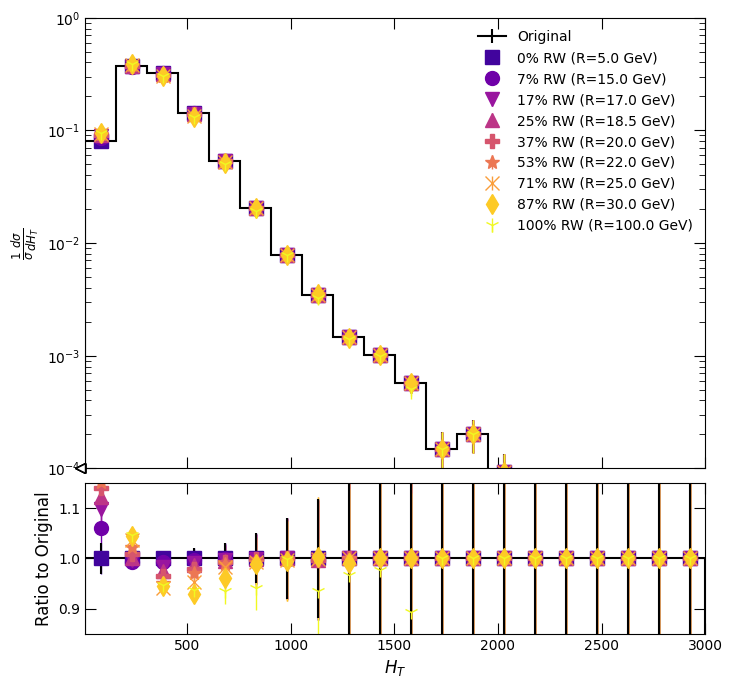

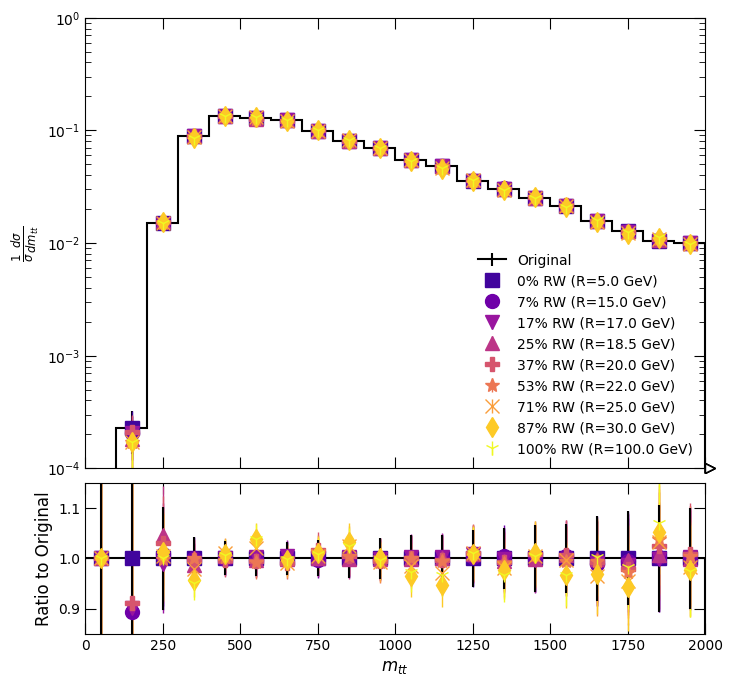

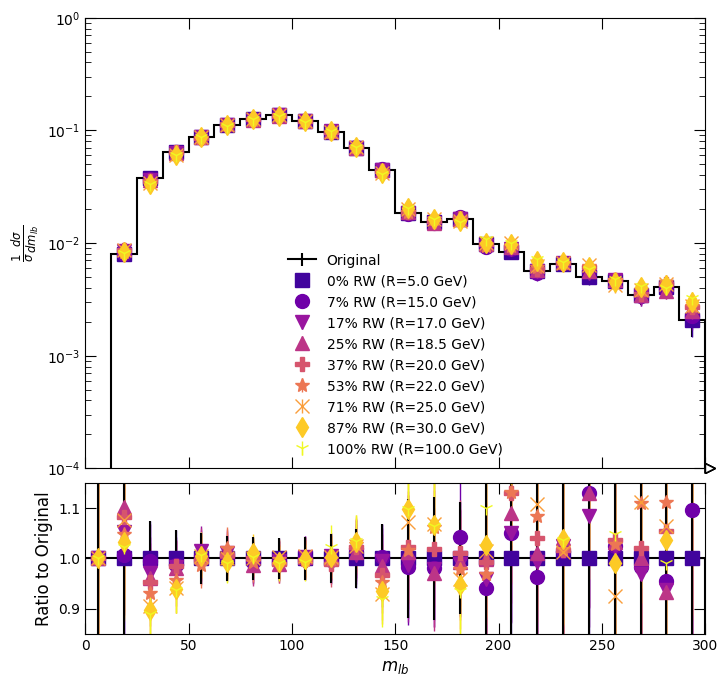

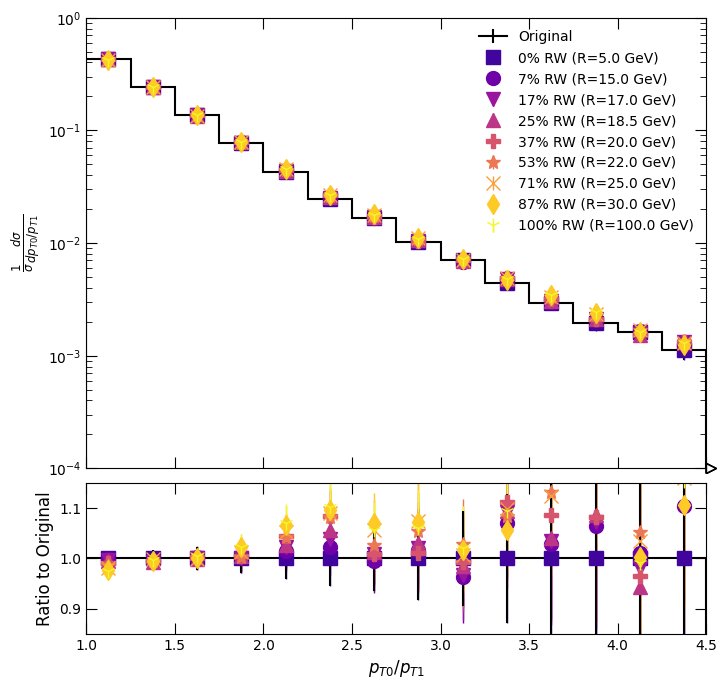

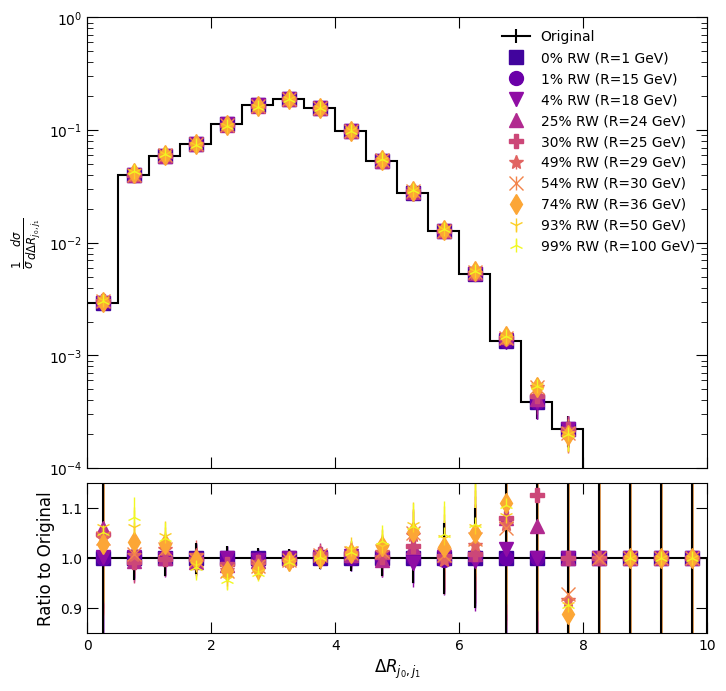

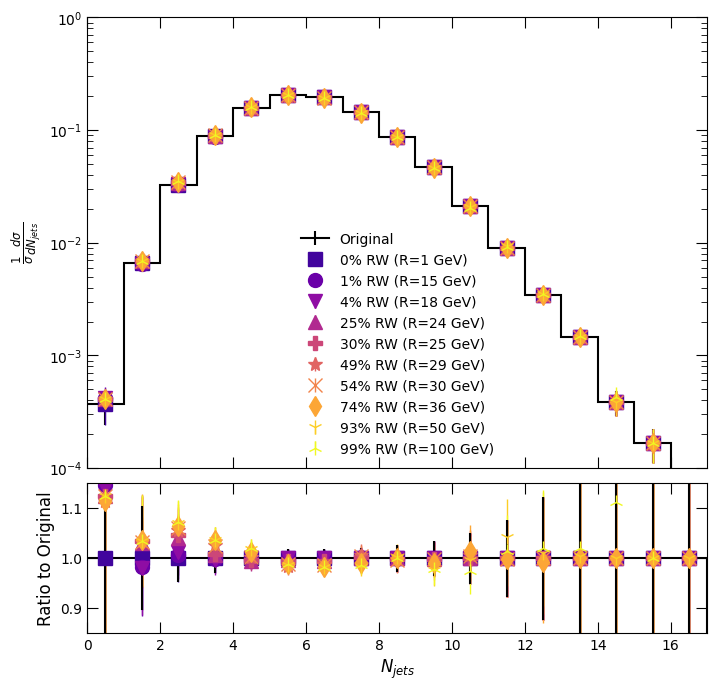

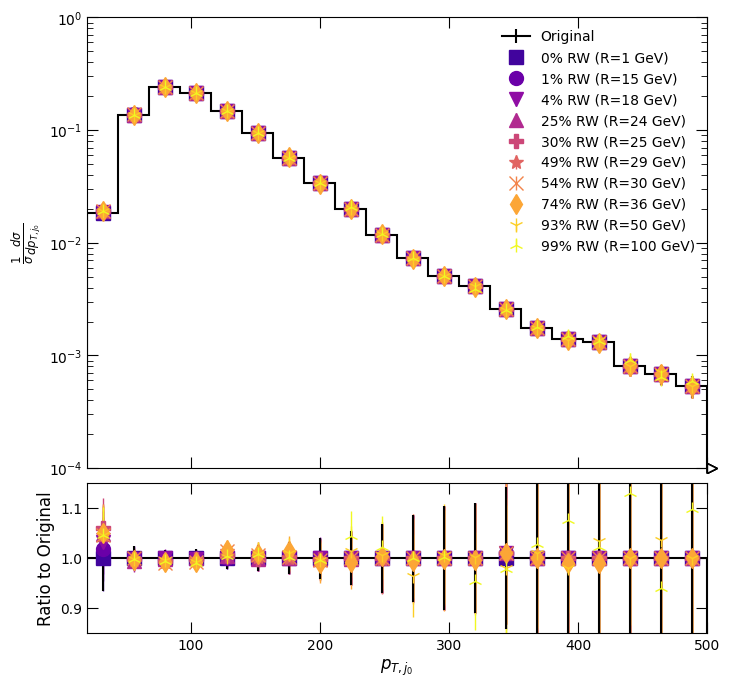

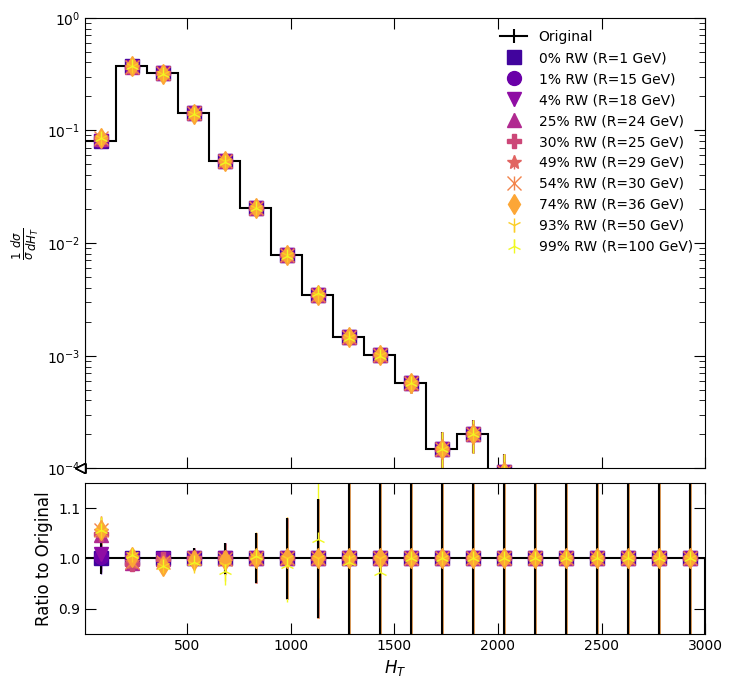

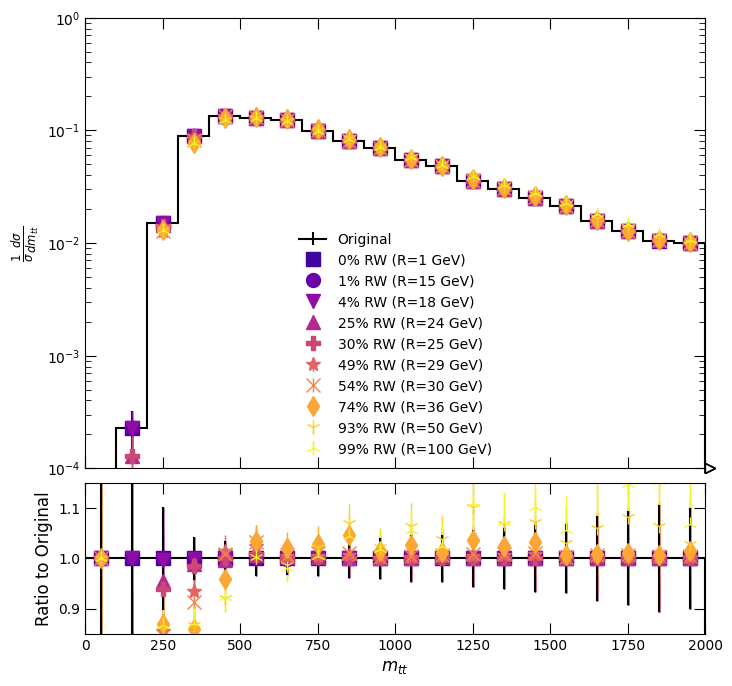

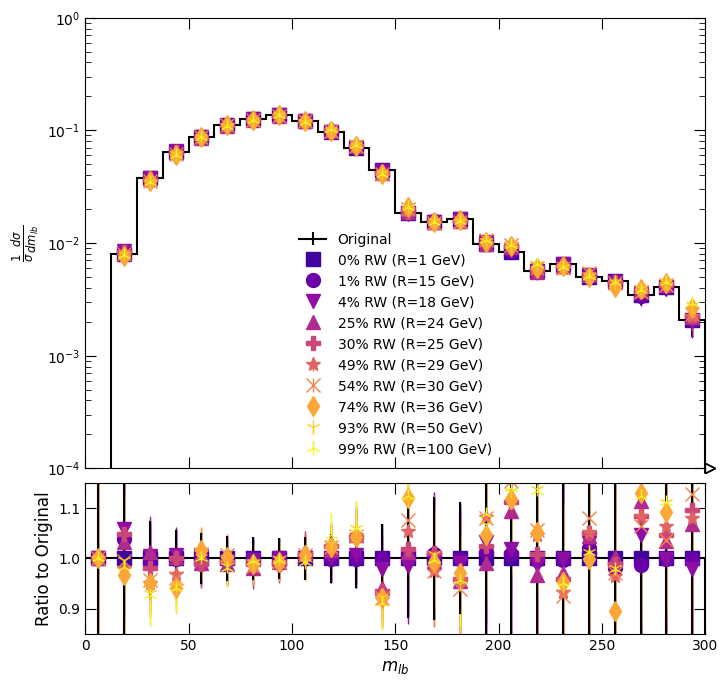

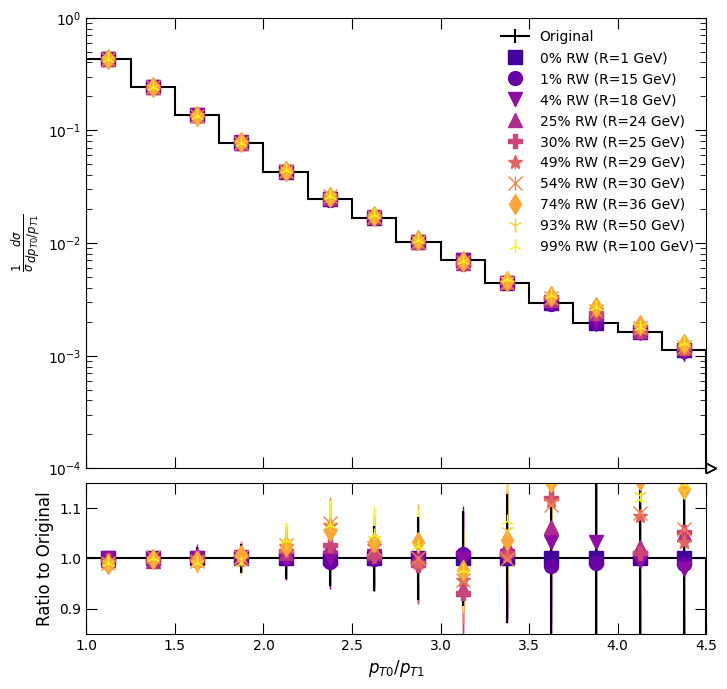

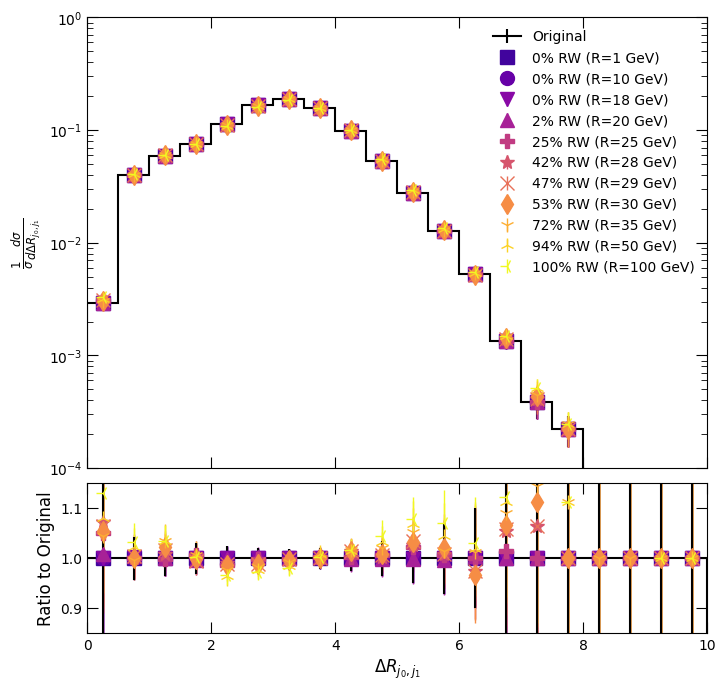

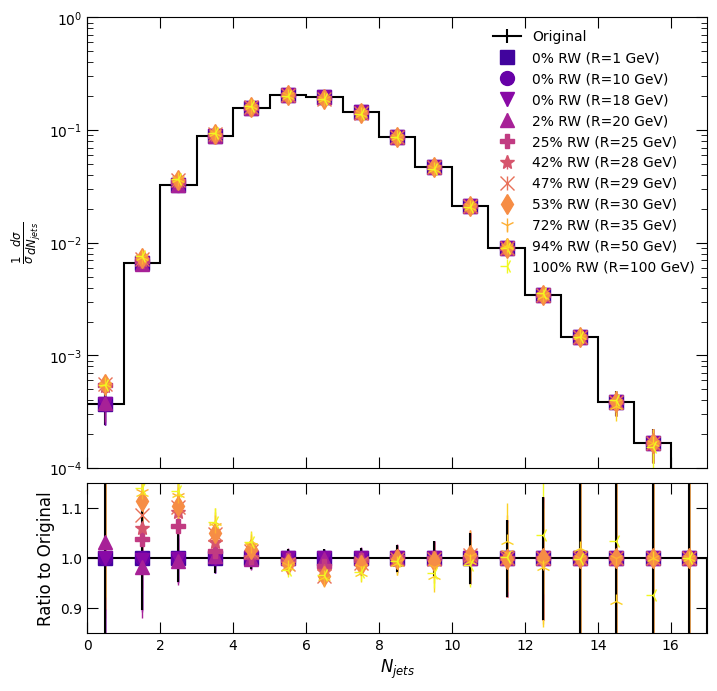

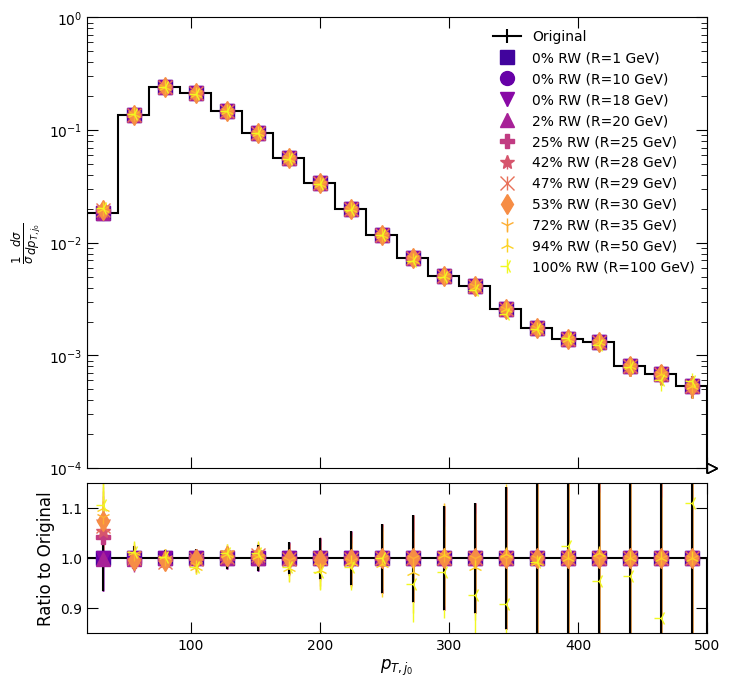

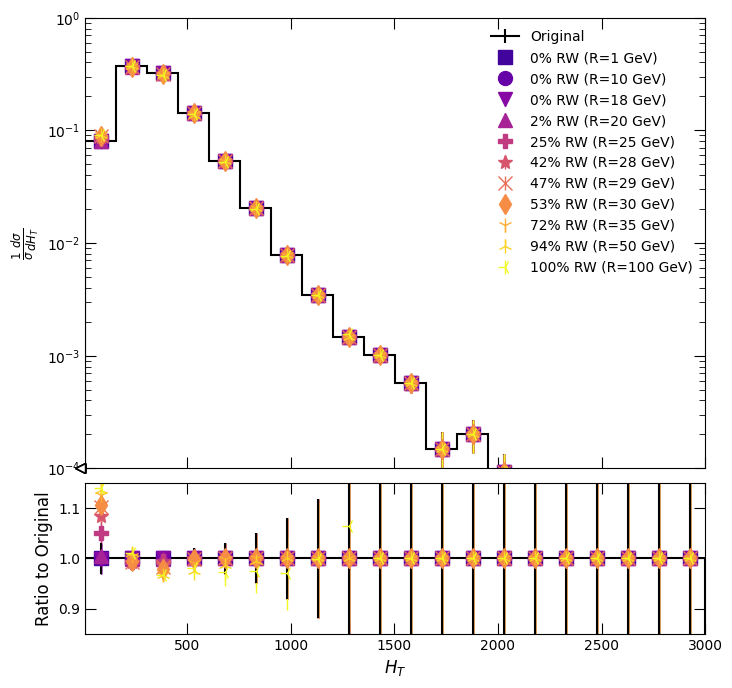

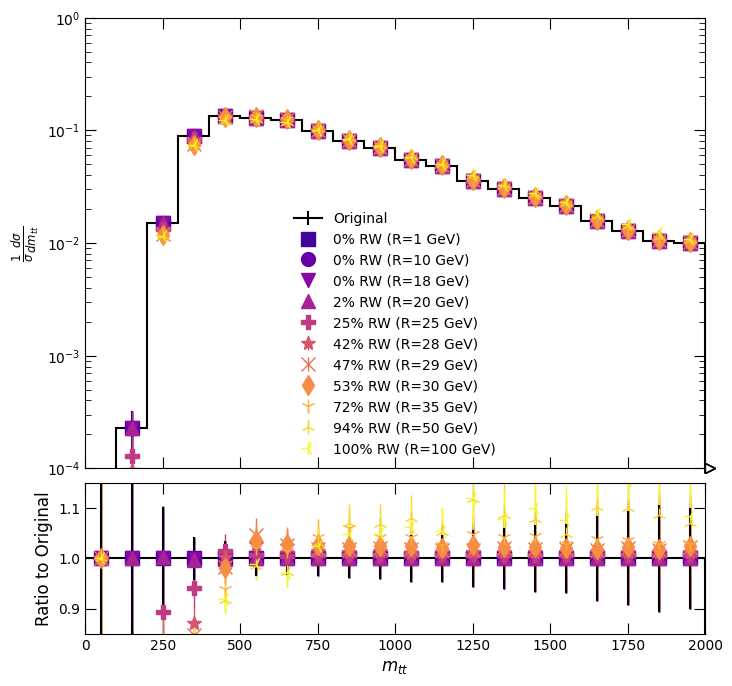

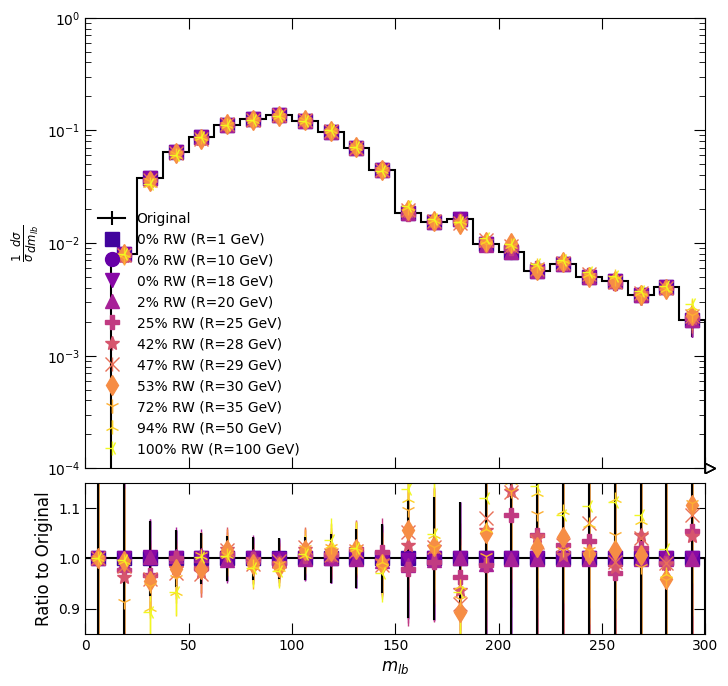

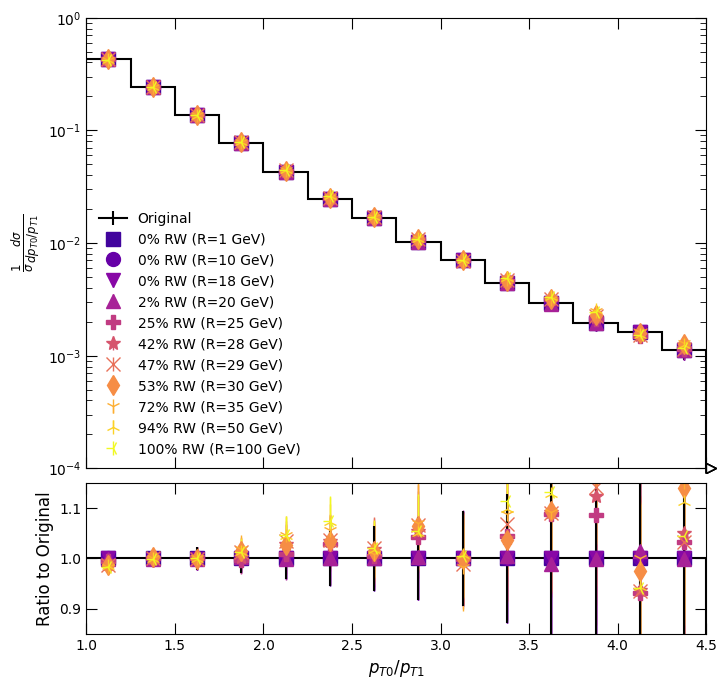

In [13]:
for dataFrame in dataFrames:
    for observable in obsDict:
        xmin = obsDict[observable]["xmin"]
        xmax = obsDict[observable]["xmax"]
        numbins = obsDict[observable]["numbins"]
        obs_str = obsDict[observable]["name"]
        obs= obsDict[observable]["obs"]
        sel = obsDict[observable]["sel"]
        ratioLim = obsDict[observable]["ratioLim"]
        title = dataFrames[dataFrame]["title"]

        process_str = processDict[process]["name"]
        processWeights = processDict[process]["weights"]

        plot_same_rw_all(obs, dataFrames[dataFrame]["df"], processWeights, numbins, xmin, xmax, sel=sel, obs_str=obs_str, obs_title = observable, title = title)


In [14]:
##### dictprocess_str = ["Hard proc.", "Showered", "Hadronized"]
fracs_50 = [0.53, 0.54, 0.53]
dfs = [ttbar_hp_df, ttbar_ps_df, ttbar_had_df]
quantity = "N_{jets}"
njets = ak.num(jets.pt, axis=1)
obs=njets
xmin = 0
xmax = max(njets)
numbins = xmax-1
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")

NameError: name 'fracs' is not defined

In [ ]:
### plot pt ratio of leading and subleading jet
# from plotting import *
obs_str = 'p_{T0}/p_{T1}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin = 1
xmax=5
sel = (ak.num(ttbar_jets.pt, axis=1)>1)
sel_jets = ttbar_jets[sel]
obs = sel_jets.pt[:,-1]/sel_jets.pt[:,-2]
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = obs_str, title = "TTbar 100k", sel=sel)
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=obs_str, sel=sel, title = "TTbar 100k Hadronized")

In [ ]:
### plot njets
quantity = r'N_{jets}' #string for labels and stuff is the observable
numbins = 18 #number of bins
xmin=0
xmax=18
njets = ak.num(jets.pt, axis=1)
plot_diff_rw(njets, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(njets, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(njets, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(njets, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(njets, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
### plot njets
quantity = 'H_T' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=0
xmax=3500
ht = ak.sum(ttbar_jets.pt, axis=-1)
plot_diff_rw(ht, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(ht, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(ht, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(ht, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(ht, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
### plot njets
quantity = 'p_{T,j_0}' #string for labels and stuff is the observable
numbins = 20 #number of bins
xmin=20
xmax=150
pt0 = ttbar_jets.pt[:,0]
plot_diff_rw(pt0, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(pt0, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(pt0, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(pt0, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(pt0, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity = "\Delta R_{j_0, j_1}"
xmin = 0
xmax = 10  
obs= np.sqrt((sel_jets.eta[:,-1] - sel_jets.eta[:,-2])**2 + (sel_jets.phi[:,-1] - sel_jets.phi[:,-2])**2)
print(len(obs))
plot_diff_rw(obs, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(obs, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(obs, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(obs, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(obs, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")

In [ ]:
quantity="m_{tt}"
sel = (ak.num(jets.pt, axis=1)>5)
had_jets = jets[sel]
ttjets = ak.sum(had_jets, axis = -1)
mtt = ttjets.mass
numbins = 20
xmin=0
xmax=2000
print(len(mtt))
print(np.sum(sel))
plot_diff_rw(mtt, dfs, process_str, fracs, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_diff_rw(mtt, dfs, process_str, fracs_50, weights_orig_ttbar, xmin, xmax, numbins, sel=sel, obs_str = quantity, title = "TTbar 100k")
plot_same_rw_all(mtt, ttbar_hp_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hard Process")
plot_same_rw_all(mtt, ttbar_ps_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Showered")
plot_same_rw_all(mtt, ttbar_had_df, weights_orig_ttbar, numbins, xmin, xmax, sel=sel, obs_str=quantity, title = "TTbar 100k Hadronized")